In [59]:
# !python scripts/run_pipeline.py configs/baseline-selection/*.yaml

In [60]:
import json
import matplotlib.pyplot as plt
import numpy as np


def plot_grouped_bars(nonseg: dict, pyvi: dict, title: str, figsize_ratio: float = 0.5):
    labels = list(nonseg.keys())
    x = np.arange(len(labels))
    w = 0.35

    fig, ax = plt.subplots(figsize=(max(12, len(labels) * figsize_ratio), 5))

    mrr_ns = [nonseg[k]["mrr@10"] for k in labels]
    mrr_pv = [pyvi[k]["mrr@10"] for k in labels]
    s100_ns = [nonseg[k]["success@100"] for k in labels]
    s100_pv = [pyvi[k]["success@100"] for k in labels]

    ax.bar(x - w/2, s100_ns, w, label="s@100 nonseg", color="#4C72B0", alpha=0.35)
    ax.bar(x - w/2, mrr_ns, w, label="mrr@10 nonseg", color="#4C72B0")
    ax.bar(x + w/2, s100_pv, w, label="s@100 pyvi", color="#DD8452", alpha=0.35)
    ax.bar(x + w/2, mrr_pv, w, label="mrr@10 pyvi", color="#DD8452")

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, ncol=2, loc="upper right")
    ax.set_ylabel("score")
    fig.tight_layout()
    plt.show()


def print_top(scores: dict, n: int = 5):
    ranked = sorted(scores.items(), key=lambda kv: kv[1]["success@100"], reverse=True)
    print(f"\nTop {n} by success@100:")
    for i, (k, v) in enumerate(ranked[:n], 1):
        print(f"  {i}. {k}: s@100={v['success@100']:.4f}, mrr@10={v['mrr@10']:.4f}")


def best_by_success(scores: dict) -> tuple[str, dict]:
    return max(scores.items(), key=lambda kv: kv[1]["success@100"])

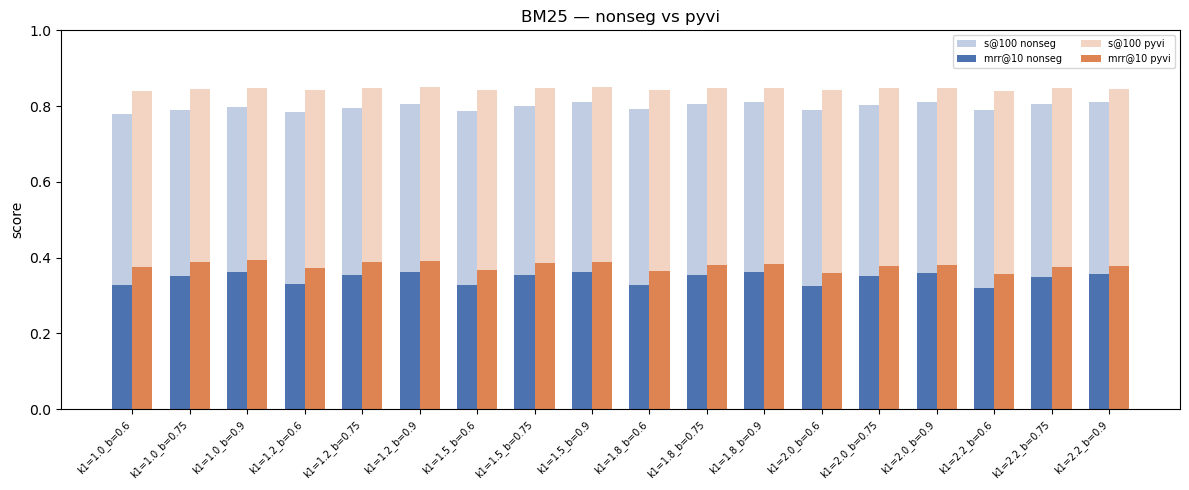


Top 5 by success@100:
  1. k1=1.5_b=0.9 (pyvi): s@100=0.8494, mrr@10=0.3885
  2. k1=1.2_b=0.9 (pyvi): s@100=0.8492, mrr@10=0.3911
  3. k1=1.8_b=0.9 (pyvi): s@100=0.8487, mrr@10=0.3843
  4. k1=1.5_b=0.75 (pyvi): s@100=0.8486, mrr@10=0.3856
  5. k1=1.8_b=0.75 (pyvi): s@100=0.8481, mrr@10=0.3817


In [61]:
DIR = "results/baseline-selection"

def _load(name):
    with open(f"{DIR}/{name}", encoding="utf-8") as f:
        return json.load(f)

def _strip_prefix(scores, prefix):
    n = len(prefix) + 1
    return {k[n:]: v for k, v in scores.items()}


# BM25
bm25_ns = _strip_prefix(_load("bm25-non-seg-scores.json"), "bm25-non-seg")
bm25_pv = _strip_prefix(_load("bm25-pyvi-seg-scores.json"), "bm25-pyvi")
bm25_all = {f"{k} (nonseg)": v for k, v in bm25_ns.items()} | {f"{k} (pyvi)": v for k, v in bm25_pv.items()}

plot_grouped_bars(bm25_ns, bm25_pv, "BM25 — nonseg vs pyvi")
print_top(bm25_all)

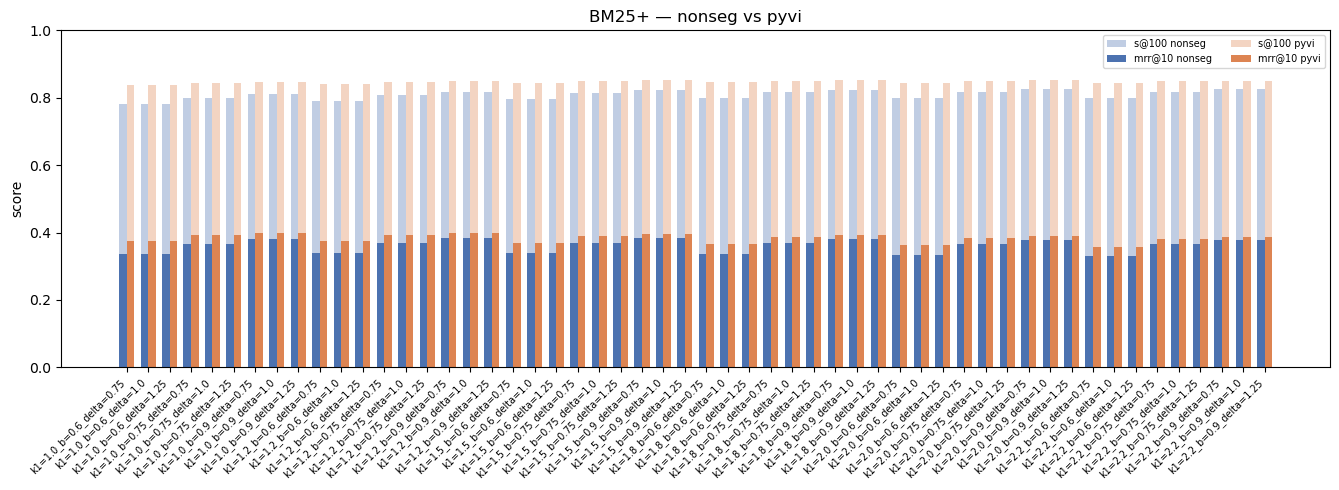


Top 5 by success@100:
  1. k1=1.8_b=0.9_delta=0.75 (pyvi): s@100=0.8526, mrr@10=0.3922
  2. k1=1.8_b=0.9_delta=1.0 (pyvi): s@100=0.8526, mrr@10=0.3922
  3. k1=1.8_b=0.9_delta=1.25 (pyvi): s@100=0.8526, mrr@10=0.3922
  4. k1=1.5_b=0.9_delta=0.75 (pyvi): s@100=0.8513, mrr@10=0.3956
  5. k1=1.5_b=0.9_delta=1.0 (pyvi): s@100=0.8513, mrr@10=0.3956


In [62]:
# BM25+
bm25p_ns = _strip_prefix(_load("bm25plus-non-seg-scores.json"), "bm25plus-non-seg")
bm25p_pv = _strip_prefix(_load("bm25plus-pyvi-seg-scores.json"), "bm25plus-pyvi")
bm25p_all = {f"{k} (nonseg)": v for k, v in bm25p_ns.items()} | {f"{k} (pyvi)": v for k, v in bm25p_pv.items()}

plot_grouped_bars(bm25p_ns, bm25p_pv, "BM25+ — nonseg vs pyvi", figsize_ratio=0.25)
print_top(bm25p_all)

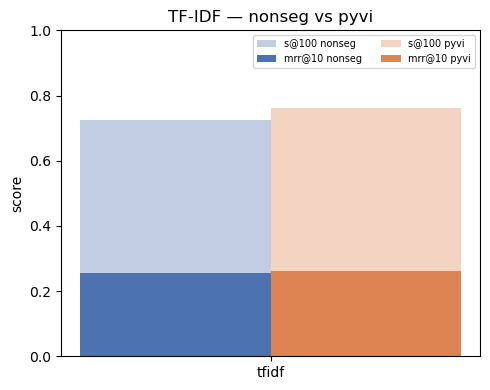


TF-IDF nonseg: s@100=0.7250, mrr@10=0.2558
TF-IDF pyvi:   s@100=0.7621, mrr@10=0.2602


In [63]:
# TF-IDF
tfidf_ns = _load("tfidf-non-seg-scores.json")
tfidf_pv = _load("tfidf-pyvi-seg-scores.json")

fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(1)
w = 0.3

ns = tfidf_ns["tfidf-non-seg"]
pv = tfidf_pv["tfidf-pyvi"]

ax.bar(x - w/2, ns["success@100"], w, label="s@100 nonseg", color="#4C72B0", alpha=0.35)
ax.bar(x - w/2, ns["mrr@10"], w, label="mrr@10 nonseg", color="#4C72B0")
ax.bar(x + w/2, pv["success@100"], w, label="s@100 pyvi", color="#DD8452", alpha=0.35)
ax.bar(x + w/2, pv["mrr@10"], w, label="mrr@10 pyvi", color="#DD8452")

ax.set_title("TF-IDF — nonseg vs pyvi")
ax.set_xticks(x)
ax.set_xticklabels(["tfidf"])
ax.set_ylim(0, 1)
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.set_ylabel("score")
fig.tight_layout()
plt.show()

print(f"\nTF-IDF nonseg: s@100={ns['success@100']:.4f}, mrr@10={ns['mrr@10']:.4f}")
print(f"TF-IDF pyvi:   s@100={pv['success@100']:.4f}, mrr@10={pv['mrr@10']:.4f}")

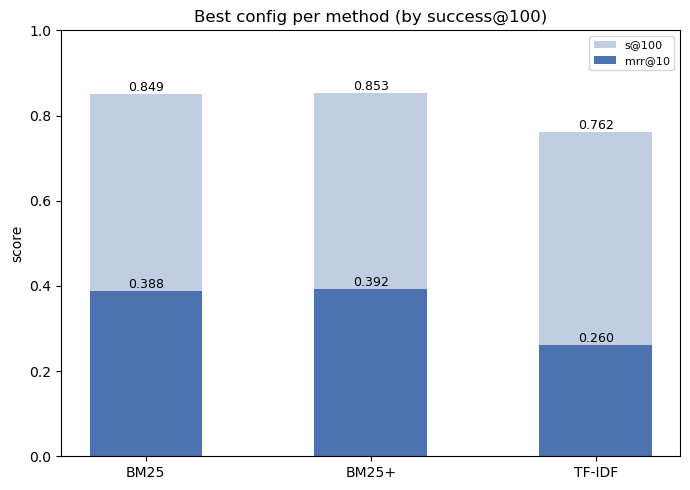

BM25: k1=1.5_b=0.9 (pyvi) → s@100=0.8494, mrr@10=0.3885
BM25+: k1=1.8_b=0.9_delta=0.75 (pyvi) → s@100=0.8526, mrr@10=0.3922
TF-IDF: tfidf-pyvi → s@100=0.7621, mrr@10=0.2602


In [64]:
# Best per method (by success@100)
methods = {
    "BM25": best_by_success(bm25_all),
    "BM25+": best_by_success(bm25p_all),
    "TF-IDF": ("tfidf-pyvi", tfidf_pv["tfidf-pyvi"]),
}

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(methods))
w = 0.5

names = list(methods.keys())
s100 = [methods[m][1]["success@100"] for m in names]
mrr = [methods[m][1]["mrr@10"] for m in names]

b1 = ax.bar(x, s100, w, label="s@100", color="#4C72B0", alpha=0.35)
b2 = ax.bar(x, mrr, w, label="mrr@10", color="#4C72B0")

ax.bar_label(b1, fmt="%.3f", fontsize=9)
ax.bar_label(b2, fmt="%.3f", fontsize=9)

ax.set_title("Best config per method (by success@100)")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="upper right")
ax.set_ylabel("score")
fig.tight_layout()
plt.show()

for m in names:
    cfg, scores = methods[m]
    print(f"{m}: {cfg} → s@100={scores['success@100']:.4f}, mrr@10={scores['mrr@10']:.4f}")